# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Date:** ___________________

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Track training time** for both models using `time.time()`\n
4. **Store loss_history** in both model classes
5. **Calculate ALL metrics** (accuracy, precision, recall, F1)
6. **Fill get_assignment_results()** with ALL required fields
7. **PRINT the results** - Auto-grader needs visible output!
8. **Run all cells** before submitting (Kernel → Restart & Run All)

**SCORING:**
- Missing fields = 0 marks for that section
- Non-executed notebook = 0 marks
- Cleared outputs = 0 marks
---

In [1]:
# Import required libraries
import base64
import io
import time
import warnings
import zlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
# Load the official UCI CSV from an embedded compressed payload.
# Embedding the data makes this submitted notebook reproducible without internet access.
dataset_payload = "eNqVXFmOJDmu/G+gj1IBkdSKuP+9Hs1I+RIeUdMPA9Q0MpXuEsXFSBq9vIv/T19V1ltequ1dXr0P/tReo5Z//ym5pNv0JbUIlpjyp/Vl5kvWS+0t/ot3e421fPEyX1Vn56rxKrLuq2ozXzXnwLLVuKy/htp1WX2VPn3ZaBPvzGXttYY/TaW9rL5Nx6vreuN9Mpf/TR/D92lmeII/tPR6fajiLf6vqfgy6S23aDb2We2lLgJfInjv6pZnlXIRR+l4DUSiLf9qVTl/P2r333WuqrlglnW+Q7TmA6qMLU0IXPzhvtnpUvMt+g6m7FfVOfETvAty78tP+17jVa3lMxXXhrP6GbAPnGz4ttR/7FKSV2kLL3uVVSkm/CvS3niVr5m4Tn2J/7j4vS1/s+9LR8P5BxfjX/5URM/zzgZ5Lr8CF5mrShyyme0l+zXl1ebM87oe/fuPNV/2rsNf2vjThp2+pr9TKCX/Wz9GX/4o8T351bRcW15aNBUXwuZjXVWGL7WKUzRfkgcevJCGM9RluUGDyvXxwu6Li3UY5aCl4pe1HqcRaHVr//5Tl0vtPdtrmmu6P6x0/5UO/mcZKRuVjpv0X/jPm5+wGhdXX+1iwc26EfR385/qq/Fs8+U6o0pZacfPpeLm2+gpZH+LH+ylNfWnvJevmTCoxZV+uWFgqz81CQY2oWVLubZybXfpu+o3yP1d/Qw6+YSOKy/auYFtJTQB8Sf6NtXmq/k2GzZWILVJvZOa5lzVLc9cAd8u4KkzJGv0JbS9Trn6hiDX27GqqzoWN2i9SR5qqPBQkErNlf5WHbirjkMZ7w9rpVyUU3kMhbHjlOndZGKFP2n1MOnLqqG6VXi4dKrLwzXAz90Xf1qE94aHvVaRlGRt8yF1F98ch+YN95zhhqz5Bmd3636Lwgkondgo4T/DMbg+cPHig82P7n++umugvx5SGrjQNfHo4q+p4V3hRmqBOrmeGpyZ/1Rbw8bpwOtsaYLT5pbT4ZYNpxq23fLEy7Xg6qrf3QwTWQqTqHQjGjbma60/X+2XQxuZiBqvdXq7IheX23DuUicdhew7gsKrO3F/ij9gDZqLLGyzGE6yVggU7mk9HIR7pApXXgochKYhuRS6fHp7iRB4yKWPv65o0LVzhblXxAoGhLIdflN9bOlPcYWGQrhbgELUdFqtueTU7fld3QrcNUDIcFouZHggl4WlcxnyMCyPfmYZn6Fx9CIwp/G8DygZNH107Latmv5ZtXyaTIT7qVtu3WCB7igR12S9GuSKg1ZeMN2V+u1Z3J42eAuPXTBY3NCgHx0Ft9j5hlK5JQRq+Bb3KX4Od0YhATeThX+70M0vS0MzbHW4TmMb4Ul5rrH4eNxTUbhnDef0M3JEAOzbwU7xHc+BH4gtVy43Gcpz0WtHyKTbh+MBqvm8hjbDY9Id930LtAq/2/FuMM8ZCtsnIxB3W2n+uFwcbUFFPXD4Tng012CBdxzEEwA6G35ddFDoNBpPv53cxP1/7nEtXj8RSqsjN2kw8/tSjeBGbWm0cSolQMKHP0BsqoehtbUVRiDQ5qveQyMS+wkNDnsVioioDu5p1PWx0iWliJZzhWbTFQIfwFIe8UoLpNlX6P/2XTYvAmpCCDBmIrML6JoQmW/WLwcajf8HPiGSajBXvx13Cu158ubygHaUSu9QR76ZuPNjLdwtXNcSe3pNQBUXYfethfkoXdeYfC7ugDG8jOdz4ebwD0FA387TTTgwCExICuI8Q8yk3gEquFuA2klY4yPMKYGfhkxwJ+FoK3bg5oyfOqaYET2b4YGTiEm5V9zfepi08P4RxJWZxEyTntXVb5QEbQu3CXPCQ1chqizhKSyu4aYqfvGCQwklYK2nqswxH+pXFj0WnZ9s7ZNV7llCqLPQRbftzwdcVO34sZ9nrRCS0Bn0MBLJ6KBLHkqKjEppqLS/YVtVql6UlMhPp+zt4WkNwvm4HZfLoOFFCB4tr6cXghBmAN2VKDY5O5UU5ub/relzZfra5XJyYbh/qis8k5ZBjaY7dw0zLtb61H4PZnUcfhQRJaLZMkBlOMK3O7H0O8Mg08YYPwE1MvKH3w+U7Y/qZ2aioikj4jmHSziy41AaeLonWwF/Zi5tAAIL+dvb9cmzsgQNhD+TGGQxY0RmWpEdTgjW91kTCDbsc9KV1HTMANrlofbwJj2dboSfUHzDHTQqigG9UN6hzHPQ3xdJaEcA9rEU9kzD6wy/paWorLlSdfcJnoC413BHRl0ZRnuKZNTNJ9YiVPuq5o8TpIiBnYCa/PK4CfHr7nQqtY7H1TpQEWY1AVRWgjIcA0lAQWx6y5iJ6JDzLGbBWF0G4we8IzJV92qG4+3gmxGI7hXHi/zKkfyHtbpM5yAa4UoaK24GSM9gCJCDMNdHIYEPIc6WuMq3+55HXFGGZ+AEaq4YV7oLKcaV/rieoAunJfZTerdWw7P50/q8+ovy2qEXIdASUA2joNxG1nvB4ENp+8QhVuGRNCAN1AsoRVBwcOzh7jCCQAYXod3OHTAqPMYCBoUjMgu9rRlccAEwCigNcrSKB7s3dntANNMEeHbsQlc4j+l3jWCoTL88Kw5VUmFaQBhAleDSCcF+bng7pcZ0OK13wqG44iLhfy8XB+28N2LByd1Woj0iXiB+Oi8Hw5FCKRHoBnYya+Z4xTxmDZeGX5gHHb2Ud1pjpLOduFbggMPJ+G+opaHZgKXpZrt+cbONqNIYWqTvdKMia34e3yItKnQz6ZLcXyl8sqM6xB5kMh4QaWC2CIiYj0sWYRQZp8zyQgwU1H9g0q4ghCAJsEaC0LGAsSeDvCdULBkgBrts8GQm0G3ukk2HF4WjpyogW8GizoBoPB/huDI7G79TLwTYI/WCBUa1AVDldI3N9lrgF8vKVZ2u5wMI872WO/v2row1k/CbKbAfpZ71ocEgKigQtSiiDNoEc32/PEJ0PBiL1aC0FvoPuyTkYwq4Iui54iEfaDCM90ClJBLFzh10oq2OelfEB9wyCh3jiKXpxymtlU5c8e4O5HE6cb9e5RbroPGOvr34CuNd/fLMyphTCIomF9ZIvD8i+V6pOljpOrKnBmv0TA9pjWdm6rZSsYfJSgWiA4BZz7hnAEa+Vd+Tb7On7tJ1TjqxEVHfd8+7dXwMqKiAVPYezGIXnSZcqiMKS31sw74vRz3PAu9HdIvAg6ffSj+HjhEmaJW0N5vtIWK8ZVL8hBc7TOqakXf6DbuO0RG6uwFArEw6WSlOXwzzgQa/XWhLIhEeITK6xkgtaaXGnBMZtnsHC0TOSGORCEMNUhk7MHJH/nW5OcRbOEiqQ4tbdreMFG0ypZ51ezeErXQ6obqBKwbLegKbfTtmAI5hoB6NVTgmqMUsV9MsUS16O3oC1InFtRMvBMBq0Agi4Mw7URdH8Qo5O10UsxCjp+y15qZXiQTcNzBQpolNZ7DuIeOWaxtQi5uvv6q38LmsfjJX1yy5ZSkSm/CDuccd/VjqqdReGoGC+UJ69Hu5QKEXKDxk+MlqKMLlR24BqS09Wxp1ZxdsL/h23YG66YlF0ZqVnY56g5vaxm6Ez35+v0vcdQ2YN1c9QL7NmcWQUr7VBmckOPQ6pe/9jlW+wbGJ++Vl2IbZc7ENAFupyqpxpDjMm1kWlB71CmTYcFINnteDy+gR3DvNeLJ2i0sPrD8ackeP2IuVG7RTanhT1swZWy29NHtAo7NoUvxCJAA3H+bKxjzLRlpRR9nzA46haKC5EolPwLHB0sW9OeC306PaOzPAlEg0B8oMDennANCpAUWQMfp18JYB4PjcBtTg2MKdna2zoEuEwbKH2+uutJktrnWta3ZeRGF2FkWe1fSKiz82jKx75ir/V3croYlQe/3tgEWZS6ky6Sz8i7LrchNa5vfmMWjQNKKCS8VZ65BDYZMEqU9BO8P/oI/tHbiWhSYgk2zfIMBPZAYsSvHW/ggtKEr+EkV16kOX+QSRSApOI17hqX0TQ76t7VH1m5FUzlxshL1mKLiMRt9PxWafpBjLCVXoVUcExGuDkK+PtmWbR7NRH3dmzMCPpXWnijL6Yy3Sq07jhpp33dgQyQnAPA4gUflmsGGJpHdJxQmf1+1vDx7XB9uIJphvrVoCLTyqH+CJ6habgGjvabUgg2SJVBIOhRsTNFXg/F1ww69oRLRiRa3RN0kb6Zvaqr+3UO9b6PUp3vtakV0vqfNWVbm7O/cue5n9RQIml9dXOM7fr+fa8/V9RpDy6LTg6CpCHQsBlcATz+15YYI9oBKygIjCOeKSqbMtsuXd2KJ7nhOu/EjDLQLei7VKsXfLLhbgBYKvn6hEpLMzZedzsYdYrXN+1oHySO1o0JR7yyTgxNkycaxs36qzwn3F2rKb937Ks+C/angoQohuRwejRsEfYbBLtGmY4NCoWuD1uVswtXweIJomstsqJte2iuQbgRx2T3gBZj3qm6k4Gv5gHS28Z94BW+QGCXhHz7Sjy0W2hM3Z3p39eDPr2vOlW38YOn0j7L4cAi76lBrRwSm13uyROx1nCFYBa8pUvD5/nzfWnudlH4ER3HHMYK1ZiZEjapTYT2zzehd5YL0euKEI9ThJuZ9koIz5a3flvjtPAtws/I79QWi0FCJc5rjgQzCy9shbgWHWV2GHNhzCJg7ZWwx7qVTirVDl7PMib9ODxtL67uDqLH9lGSAviibIBK3jSxOxUjbRWZE2dgwf/aLL0XiokRFSnXRcpNvGUSbc4Rpg/3K6XuqRLLaySSW18xora7QnVScLjrZr/avV/aTOzjpeuc52twt6yLeGuL72m3q9cDWCc5KSLIckz7cgz45sJow/+Dthju2Iz7WxXtdZ/ay73t0AhTvQ67sDkUQgrRp6Ej5xB8fy+UgkOQEjsLPtklXK2cYWwqjGmlltfe9ujEunm9rWBnlKfXeLutqF4UOQF9lBK3KEtPapb0aUsvVNI0Leb7XxLvoR8Xprj4u3273Pqv+rGUtwepFNodOTrGGUk4Qzx+epQn36wQIw1c+7j1MNmdv4WPW9clQq1YzVRt1nX6iXdMC6twdTx0xZCInOFA/a51YnFt/LwQViAYQer/bdRukn56rSLQnZGr6bdXiI8o2dwFIskGdmFFHeK6eRIFdXMmLKwQdy7CqXJcx8WZ6mvoQdjfntfSUASBRlyoZ2rF99HJBL9gFRH6lfHmdyWVv2Uetq5+MWE5YC/kBUd+IlfNw98hyPY5XEes8IMbr8fjXXnq+evX7KReUml1ovFlhZQUFvpDBNSnFgiecaLtEuGb7coJmslkbuYdn8HXbuPkId2sm4VTJ06phHJbZGvwftCPic4CTMmkVCdFB20qNtfEFHleg9CjPoTuZ214UkMlY7lvS2l1R4PBAFwJcDgFsJ5KKhzmpBOTr7Yg9d5vNOZZ7ZLLkXXYeuc+1RJKhfgd517bbuscZvWd5E2fvlEhcrgcPomI5eNUsO/2mLNSoOj1SMdZIkf/aDLSYgRz6wTayVRl+kW3MVmAnZIipbheUn1MaRafprelBclKjanfoVM0eXLHDkprVVMCc+0yrgeYb1aGTULF8s1G4r+xsoi0jeLK1/0VMs6VvsSFUeJ4omEWAxTj92dVMe1jOKXayno6J7qg+pYW4uwVWzrbHaH9dH8uy+vhlUlI8ldJOXG2YdgyWvOj26pMxZd2mBIHeZSOXSuY6eZaDqPnYEb+Upfjr5U/xW6m9BEWRuQUF5yqcU2pK7FKo8NqX3TZVTlsrKPDAt9XFtNLuuCUPuu9z3PRBYB2wPRVC8I5ymHQXT6j+rCRZhCoqFkpUsNNbdisnIaTu/ZWG1ozG4n8kuqEVOQ+TrylZ3TQNbbIu0iyNyV3qWuQN3kSgfjUxBh2RMZgE4U0K0TqOfBOJqtlwsa/FEOizuk11W1m650L4ry/e+iYgW4JeyxlCD7ZfOj01595S+i97YJGSri52cZDXpJq8OwMwOgtR7ke0ZCRxMXKNvx/4MCR7gGfi7PZiPmcy7SqZhzdi46I3QCW5T91pRdFZrAspBMnMwo2ou7mSOfD54sLS7aLskCukbzv+5h+A3gafNPZSZawtyJBTwgeILQknQPhFNg/NFikIUs1t2HDyBckgVD3Y3M6NvykR9xOF6VEDXhNH2dC9Mzfsm5QzWprBUUY+P/S7LMgzsm917Ok9ys7hfwRYeYgCTe59tROdWCvgi7CmhW4Vae8iBSt6ZORX2bIhdgg+HrhqbwqRF6rU4VCx1jPQstcH2jgYrBWZYaD4a6UJ9B7NwwSIqeC7vNkmqo6ofowtI32S38Nm/7p0Pdr+D7ZEfZmiHWGzZLxnWBvFgyxNhrwd3mQRgOtBFZ84edYgSgORjF2ipM+BGOE06F9zlZNLs2g0bXfAXf2R3Z5h/me2a3pz10ccQEoCUHdZCX6jpsvojTt9Zj2TuJHMwmA8ux+smUN45KJJycFDgTtDBgHG2ZdFLAU1IQXAs5Oulf4BS/sQK6wZnGJh+IVcGjI1cN/R59KbZncnYvsbmZJf1OFtJTmEEomG6L65/q9vwsjI+zJhhYNlWWGpH29ygNY2GbJFW8E8ADwKVkdXgDg5VX0ELxmXaM8YbyTKF9JBAxBXx8JLY/UF2yTSSpBJLx26mt2W7466c0yi6cQgDwKik5RkSGEtSalBuqObZIiIlm2SdiSe0kDZtPTr+knUSzn64cqPZnLkU4wMx0wzWUrSEB9A30RVUfJuOMUBF1aewr6bB04Db/ai/+M5ll2GD5ZOsSVatb2Me4My3TIsksMNZ6bovRWGPRdig1iQFGFS7lidDbVeiZ0Q3Tbo/mrybIqF1PQccOqOfBMU7a2MteNgDnMxTBmi20BwHm+JtbWLx6EzsC4khlcMWwpEdosweXb3EAKylfAj3T8RoCcQc/d6YwEGBGWQR+E5BQgxqiRAyQylJv2uSPF96G3crCEsGiVQobWEtK8Zf4ENaDnG03n8N3cz7zM2YUfG0C8vmJEsUSfpBDD8N2AIaGKBDW7D4yJYnOIxJhWNgrfdvIwCjr3M0SffaBf/YQZxAFIyOH7wx++2sSNddSeUcC9JZ1A8byVaW/KkR+eWU9CCVHLI77bMmYSW4OOXgdMKE5kCtC1yFXqKbgwIYThJQoCV8UhSdP/IOIUUh6r8IbLsGQGfzsRY7HQx67PO2DWHbCC71iGbokRq2dGKo7+4CWoE3R+e4XlSN13hC+pkRXjGq4zkEYM2m/WkWHHOsSi01p5A8g0Ix+pvBjle2CJH/xYxCMIIsZhTgxPwwyq5/nG1xqohhuK2jNCwxrIS3Oj7pGZPgcgd9yQoIVwFsKQbXJw9qewoMQx2cFQkgG1bR1sPoKzuKLrZAGDYOkyjRCIV/LZ6JFtBO/2RPnk112AX3Fd1BsovdnzvWOhj4k9C/teyEJgcfWOux1kgNirUjCGm0N2DOUgkv5+LYZPaDN2O6qCRjWpDTtBFBpTClJv6vtg1jRnedkpls/JMyMjjVxu5XdGUJXUZLn9ZR6wNoqWR2WHo68ozXbvFZxqvCGiI63WXknJ0Srlj05l81qXIL7SRHTzAtj65Ik0K3GmdfouWwqUmLFGLhrfsJca+EQS3GMFjHrHvAkiS8KAYMOXuHJCqxwuR/v9LorbToHRr5sCnfTlqdMTlFcyXdzpeiW7BHA5/2NXcZVsuX1ouyCcFicT3HmUqQKgCG0auDWGGaKyZHSc1uOXe2UAH7mAj6wHoznWTBQOlv/kMMUmz+A5KR8uA0gEDEur605IaWRCpYaz3YB4hX/qz+/gMGACiRlsN84Y8KGZGY+PVVI0gbMUExyRJYm3uUaTHGCcHg8ag2knsx33/gWzqnOnjtK4nShRz4gazOowsKj4F+kewcnKp+jPJwK35K1BWmMCHtmyfOP8ZftusUwH8qN4Ltp9/GapjBJajVXTWuX4ZL7gC4H02mqj8DXVShLpEOyf+jIozHHrWmtbdLBvRj0o8w+MVprbI3sPq3g3U7e7DjiF2svz+U/obA28YR36ZxDiFE2egQgtr8eTI+dh8MOlYehPw/aN5sRFVY2NbsrSyWaxBrhWPv8A9BmSssKGX5AY1tfcwPWNJOKyv9o4095IMg81gb6H4GLJJc2mqQEdwiwL7MkngwqkjTxaRLJP729akRlMVCa/YOBOMDqMHEzcDo6zoo0+0a4eDV7ZhijFS3JZc4sAf36HaLpCteLInLglkP8duu5q8aUbscilVPnxMzi+WYcRrIRgHUUYBvGHoIbjmTm8Xp3LnJGOy0CymI7g8a87uSBT0N/IUR/eTEULvApEWUNlxf9NiUKX/M9LJ+evbiFuIki2xBDorDhQ0X0vGS8RmcpyB+t0VIGUGWj9ZINGcm0SxOP6YohR11pa8vGSOjQoVtG2dZpAU4jHHjy7N1w0rjaowZwvnVoH+wxmjH6l43TYhp97NOG5NScTFS9wcKkMgNBp9pSRxF727l2sLCcoLm+RfhRR9yCy/Htp+LG7l+2Yo9aFgVgfGL7Gy1Y/WQXbfppT8fDf4dJ/xn5Br7xtuS38IgIt/CwMTi/N3bqHLrbfQvXYPdrOHSS7dGn/chbKwEfbrwFZv/0n5SR2K87mCO3Fg8q9E/zZlttD0U709jUhalCAna7TtwRMieMO4kf1kKHXzTjWSjlnOZ0CRJnqOEJcbQsyaOtA7Fmz0oRGVm78g9wNFtIlfgWCassqAmRevb/LXS19kAwdCFJX28H9M1pVz60twROTOvoxMz5fx9FnwuUQxq1x8L9Lqk52YNqcGi8sZ4IGdyWA5AmabsedkrVSa3FKsO6kLRC7HKUmNrTo9llws5w4MtVfplbd8VQfauPtZaMJ/zKFsJZ5P//FSiPrQVfNURrYKhC2YFKR1D08C6fDCEQjni1ns7eJnrJp34Esm+9d4OskR7Hr4k53gmXSI5irCU84HoNtgeGD7GhhGyhTHN0wtMs0Si45CTzWwiTHAto4JWTt6McgryADMHgWeS8o1czoEE0jKJCSHME/VgL0f9CbkWdGCsz68PFLZyzq8PjKVf5t6vH34x3Rq78AWSj4/EfHypoJaoyeDX43OkTzklqxxOQdtLEiBMMJwqdoiawZ7VpZByfidKlyy8xVgOsshdfD22kEyksT9U023+/K5B8F8+vmvwoIx2piXGtOdg7vDDCo9PEKCqkRG/tHawJ2JWDNkeyNQx86QxsBFcuqNSOzEH/cDKq7FSSDb9auugA9/6pSN1RciPykxB1k+SGpO9sxRkl54xZ7D2kPjxGYs6Lg3VyaKWklXejxzmc4AS3x+ZBFSXufwOguy3SVbOA9aYJK07isegx+d4tNJh83sq/KjJ5p5okGhxD3taCRm75mJwsusm8KCsF9MbrWehK3QN0txfDAn0s8B4y+nnUjlCHtQM2rBECb/uSWHRb9+BIUGYJRF/3Nw07fqscAZjRsmmi6lqyU98PIe8hDN5ZLLmRy3yw1f92xhLFE5JFABfco+xWP/2LamDxzjrpsaKPCdT9hSW5AeiNluVdMTHBHJgS5K/1beRgyWoqX2wpDfzOcYLHPvutd+GhK+f0phTMvaXPX0MggeHdfnJp5qhQVjWzz4yFOdRjK1E2Wg/CD+blJzEHoOvUeStbI0ZcRJIbcx5xPaQLIg8qDehGA0gG2GCTANmUP73oY8rBmo/OLY57bPjewNIXcLqjWA0r2/Xz3vqMXnEIVD+tT0+lhQTnKEHpe2OWsxdfQ6sSzvZfSAA5pcavujAbQBcEzsfXyN6DH95VOD10Kur5YDfQqXiMfzVohbNGDQ28l3yNfFO9WbB9hyinCjyhNUMi1l9eKRmhD+xh+O7UVEABSX9jVGTGMQ25iE1XHr8ZWTJM+eaIbcaX6gh7OHkET/Bhs97ZQ+ooA3Y4R7Ojw3EJWh+G0Bss2UEfnvwi2Frk8XAUR/vCPh7bD3ymf7Q3WPOgYYxk4eyolrgugCrBFEgGMovztusvrKIH+P4JFR2NqLmbtIL23tIeTU75MEVIr/kQvkk8eqdlIFAMOEa57di9GDmMGOCRfcHiQabdsDQZwH/FuX3t/tiov+aZgg9AsRa37v/kEHrjGCNbYMR1P6yrZuf9/icm1i3uQkyjX9x6+WeIRX5y4xFv45YlPPzWkeJoY23XAu3vwYFyn1QwES/sqtHcPjW0Vay78Th48NndT2oxcEH3tRijW+IXAd3Av0E56RtIDvmSRqOr3ZIC5h2PKdd8EfEyiCb2VFsW1+6/qB7bW7rHhWDP1tfanjXtVbzsRyU+G9LL4zfSorBJr8eJE9+b+hHRt7qLSMnteaDYdz7jWHcynrwZNu4Mf36KI9eCZSOhBeOmkgJWOKpBRtiEbfaiXfiW28sgM25sik3VR7cuXGjzlXU++GtLywi0kMODl3tY9OIYvgGVXVWmtCqsx00lPg6OAT5mT5b/w9q63hwNiytPwmNssenbcpvLkh0JQ8uiECtf60t17X5RSBOMXIuu46V31XgHCEZG63iYyu8G3rrj64Z2Cv58bho+e0BrUYmHL4w1TKRjSpBjZj1ioFJkjXrA0fuMfIx9fjiIzlV2MIM9iqanTO8ML5LYWzdQ3WDuIeWtn6JyhIfUCH63zPZFgnCveEZ2fA2lHl8Sqv2+F4DwmyjWjOCk7PHL50wR42PuAwCg0cHk7lWfBsqKIz8tANY7fiMJkrZY3DWgj2a6N1x4j1Kz1QUKSTZdQ7AziAOcfkKkn7UhnYLkQSK+0c9NzsFob+w+ZfwQuWvX0AC21B2AOdXarF3XPNkd/82Oqz8CNBGVIu5Lyg6ZYQbYgOPTZLIx0jByarFf/RugBzlP44XANvLA3/BzxFG0JWMsllgLT4E2FDJ2R9OKPxeGtwG2w5lW+hS/UnvLevG7u1Xdm9U3oj7jjiOr0toDUaKB6CgElnMbpMMMus6Js3lXn+MSd2sXo16FDjtMjnU2b4SSVrYHi5an7W6ew1yN0zBD78M9iiR5bx89FJjJPb/AEq3mGI="
csv_bytes = zlib.decompress(base64.b64decode(dataset_payload))
column_names = [
    'TPSA_Tot', 'SAacc', 'H_050', 'MLOGP',
    'RDCHI', 'GATS1p', 'nN', 'C_040', 'LC50'
]
data = pd.read_csv(
    io.BytesIO(csv_bytes),
    sep=';',
    header=None,
    names=column_names
)

# Dataset information
dataset_name = "QSAR Aquatic Toxicity"
dataset_source = "UCI Machine Learning Repository, DOI: 10.24432/C5SG7H"
n_samples = int(data.shape[0])
n_features = int(data.shape[1] - 1)
problem_type = "regression"

# Problem statement
problem_statement = """
This regression task estimates the acute aquatic toxicity of a chemical toward
Daphnia magna from eight molecular descriptors. The continuous target is LC50
expressed as negative log molar concentration; higher values indicate greater
toxicity at lower concentrations. Accurate screening can help prioritize compounds
for laboratory testing and environmental risk assessment while reducing time, cost,
and animal testing requirements.
""".strip()

# Primary evaluation metric
primary_metric = "rmse"

# Metric justification
metric_justification = """
RMSE is primary because it measures prediction error in target units and penalizes
large mistakes more strongly than MAE. Large toxicity errors could mis-rank hazardous
chemicals, so emphasizing them is appropriate, while R2 provides complementary
explanatory context.
""".strip()

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")
print(f"Target range: {data['LC50'].min():.3f} to {data['LC50'].max():.3f}")

Dataset: QSAR Aquatic Toxicity
Source: UCI Machine Learning Repository, DOI: 10.24432/C5SG7H
Samples: 546, Features: 8
Problem Type: regression
Primary Metric: rmse
Target range: 0.122 to 10.047


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [3]:
# Separate the eight numeric molecular descriptors from the continuous target.
feature_columns = [
    'TPSA_Tot', 'SAacc', 'H_050', 'MLOGP',
    'RDCHI', 'GATS1p', 'nN', 'C_040'
]
target_column = 'LC50'

X = data[feature_columns].apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(data[target_column], errors='coerce')
missing_before = int(X.isna().sum().sum() + y.isna().sum())

# Use a reproducible 80/20 split.
X_train_df, X_test_df, y_train_series, y_test_series = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Learn imputation and scaling parameters from the training partition only.
training_medians = X_train_df.median()
target_median = float(y_train_series.median())
X_train_df = X_train_df.fillna(training_medians)
X_test_df = X_test_df.fillna(training_medians)
y_train_series = y_train_series.fillna(target_median)
y_test_series = y_test_series.fillna(target_median)

feature_scaler = StandardScaler()
target_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train_df)
X_test_scaled = feature_scaler.transform(X_test_df)
y_train_scaled = target_scaler.fit_transform(
    y_train_series.to_numpy().reshape(-1, 1)
).ravel()
y_test = y_test_series.to_numpy(dtype=float)

train_samples = int(X_train_scaled.shape[0])
test_samples = int(X_test_scaled.shape[0])
train_test_ratio = train_samples / n_samples

assert not np.isnan(X_train_scaled).any()
assert not np.isinf(X_train_scaled).any()
assert not np.isnan(y_train_scaled).any()
assert not np.isinf(y_train_scaled).any()
assert train_samples + test_samples == n_samples

print(f"Missing values before imputation: {missing_before}")
print(f"Training feature shape: {X_train_scaled.shape}")
print(f"Test feature shape: {X_test_scaled.shape}")
print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Missing values before imputation: 0
Training feature shape: (436, 8)
Test feature shape: (110, 8)
Train samples: 436
Test samples: 110
Split ratio: 79.9%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [4]:
class BaselineModel:
    """Linear regression trained from scratch with full-batch gradient descent."""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        """Minimize mean squared error using analytical gradients."""
        n_samples, n_features = X.shape
        y = np.asarray(y).reshape(-1)
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            predictions = X @ self.weights + self.bias
            errors = predictions - y
            loss = np.mean(errors ** 2)
            self.loss_history.append(float(loss))

            weight_gradient = (2.0 / n_samples) * (X.T @ errors)
            bias_gradient = 2.0 * np.mean(errors)
            self.weights -= self.lr * weight_gradient
            self.bias -= self.lr * bias_gradient

        return self

    def predict(self, X):
        return X @ self.weights + self.bias


print("✓ Baseline model class defined")

✓ Baseline model class defined


In [5]:
# Train baseline linear regression on the standardized target.
print("Training baseline model...")
baseline_start = time.time()

baseline_model = BaselineModel(learning_rate=0.01, n_iterations=2000)
baseline_model.fit(X_train_scaled, y_train_scaled)
baseline_predictions_scaled = baseline_model.predict(X_test_scaled)
baseline_predictions = target_scaler.inverse_transform(
    baseline_predictions_scaled.reshape(-1, 1)
).ravel()

baseline_training_time = time.time() - baseline_start
baseline_initial_loss = float(baseline_model.loss_history[0])
baseline_final_loss = float(baseline_model.loss_history[-1])

print(f"✓ Baseline training completed in {baseline_training_time:.4f}s")
print(f"✓ Loss decreased from {baseline_initial_loss:.4f} to {baseline_final_loss:.4f}")

Training baseline model...
✓ Baseline training completed in 0.0207s
✓ Loss decreased from 1.0000 to 0.5158


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [6]:
class MLP:
    """A fully connected regression neural network implemented with NumPy."""

    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        """Use reproducible He initialization and zero biases."""
        np.random.seed(42)
        self.parameters = {}
        for layer in range(1, len(self.architecture)):
            fan_in = self.architecture[layer - 1]
            fan_out = self.architecture[layer]
            self.parameters[f'W{layer}'] = (
                np.random.randn(fan_in, fan_out).T * np.sqrt(2.0 / fan_in)
            )
            self.parameters[f'b{layer}'] = np.zeros((fan_out, 1))

    @staticmethod
    def relu(Z):
        return np.maximum(0.0, Z)

    @staticmethod
    def relu_derivative(Z):
        return (Z > 0.0).astype(float)

    @staticmethod
    def sigmoid(Z):
        return 1.0 / (1.0 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        """Use ReLU hidden activations and a linear regression output."""
        self.cache = {'A0': X.T}
        final_layer = len(self.architecture) - 1

        for layer in range(1, final_layer + 1):
            previous_activation = self.cache[f'A{layer - 1}']
            Z = (
                self.parameters[f'W{layer}'] @ previous_activation
                + self.parameters[f'b{layer}']
            )
            A = Z if layer == final_layer else self.relu(Z)
            self.cache[f'Z{layer}'] = Z
            self.cache[f'A{layer}'] = A

        return self.cache[f'A{final_layer}']

    def backward_propagation(self, X, y):
        """Backpropagate the mean-squared-error gradient through every layer."""
        n_samples = X.shape[0]
        final_layer = len(self.architecture) - 1
        y_row = np.asarray(y).reshape(1, -1)
        gradients = {}
        dZ = 2.0 * (self.cache[f'A{final_layer}'] - y_row)

        for layer in range(final_layer, 0, -1):
            previous_activation = self.cache[f'A{layer - 1}']
            gradients[f'dW{layer}'] = (dZ @ previous_activation.T) / n_samples
            gradients[f'db{layer}'] = np.sum(dZ, axis=1, keepdims=True) / n_samples

            if layer > 1:
                dA_previous = self.parameters[f'W{layer}'].T @ dZ
                dZ = dA_previous * self.relu_derivative(self.cache[f'Z{layer - 1}'])

        return gradients

    def update_parameters(self, gradients):
        for layer in range(1, len(self.architecture)):
            self.parameters[f'W{layer}'] -= self.lr * gradients[f'dW{layer}']
            self.parameters[f'b{layer}'] -= self.lr * gradients[f'db{layer}']

    @staticmethod
    def compute_loss(y_pred, y_true):
        y_row = np.asarray(y_true).reshape(1, -1)
        return float(np.mean((y_pred - y_row) ** 2))

    def fit(self, X, y):
        self.initialize_parameters()
        self.loss_history = []

        for _ in range(self.n_iterations):
            predictions = self.forward_propagation(X)
            self.loss_history.append(self.compute_loss(predictions, y))
            gradients = self.backward_propagation(X, y)
            self.update_parameters(gradients)

        return self

    def predict(self, X):
        return self.forward_propagation(X).ravel()


print("✓ MLP class defined")

✓ MLP class defined


In [7]:
# Train a two-hidden-layer MLP on the standardized target.
print("Training MLP...")
mlp_start_time = time.time()

mlp_architecture = [n_features, 24, 12, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.005, n_iterations=2000)
mlp_model.fit(X_train_scaled, y_train_scaled)
mlp_predictions_scaled = mlp_model.predict(X_test_scaled)
mlp_predictions = target_scaler.inverse_transform(
    mlp_predictions_scaled.reshape(-1, 1)
).ravel()

mlp_training_time = time.time() - mlp_start_time
mlp_initial_loss = float(mlp_model.loss_history[0])
mlp_final_loss = float(mlp_model.loss_history[-1])

print(f"✓ MLP training completed in {mlp_training_time:.4f}s")
print(f"✓ Loss decreased from {mlp_initial_loss:.4f} to {mlp_final_loss:.4f}")

Training MLP...
✓ MLP training completed in 0.1871s
✓ Loss decreased from 3.7927 to 0.3095


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [8]:
def calculate_metrics(y_true, y_pred, problem_type):
    """Calculate regression or macro-averaged classification metrics from scratch."""
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if problem_type == "regression":
        residuals = y_true - y_pred
        mse = float(np.mean(residuals ** 2))
        rmse = float(np.sqrt(mse))
        mae = float(np.mean(np.abs(residuals)))
        total_variation = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = float(1.0 - np.sum(residuals ** 2) / total_variation)
        return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

    if problem_type in ["binary_classification", "multiclass_classification"]:
        labels = np.unique(np.concatenate([y_true, y_pred]))
        precisions, recalls, f1_scores = [], [], []
        for label in labels:
            true_positive = np.sum((y_true == label) & (y_pred == label))
            false_positive = np.sum((y_true != label) & (y_pred == label))
            false_negative = np.sum((y_true == label) & (y_pred != label))
            precision = true_positive / (true_positive + false_positive)                 if true_positive + false_positive else 0.0
            recall = true_positive / (true_positive + false_negative)                 if true_positive + false_negative else 0.0
            f1 = 2.0 * precision * recall / (precision + recall)                 if precision + recall else 0.0
            precisions.append(precision)
            recalls.append(recall)
            f1_scores.append(f1)
        return {
            'Accuracy': float(np.mean(y_true == y_pred)),
            'Precision': float(np.mean(precisions)),
            'Recall': float(np.mean(recalls)),
            'F1': float(np.mean(f1_scores)),
        }

    raise ValueError(f"Unsupported problem type: {problem_type}")


baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)

baseline_mse = baseline_metrics['MSE']
baseline_rmse = baseline_metrics['RMSE']
baseline_mae = baseline_metrics['MAE']
baseline_r2 = baseline_metrics['R2']
mlp_mse = mlp_metrics['MSE']
mlp_rmse = mlp_metrics['RMSE']
mlp_mae = mlp_metrics['MAE']
mlp_r2 = mlp_metrics['R2']

# Classification fields remain structurally available but are not applicable here.
baseline_acc = baseline_prec = baseline_rec = baseline_f1 = 0.0
mlp_acc = mlp_prec = mlp_rec = mlp_f1 = 0.0

print("Baseline Model Performance:")
print({name: round(value, 4) for name, value in baseline_metrics.items()})
print("\nMLP Model Performance:")
print({name: round(value, 4) for name, value in mlp_metrics.items()})

Baseline Model Performance:
{'MSE': 1.4577, 'RMSE': 1.2074, 'MAE': 0.9082, 'R2': 0.4756}

MLP Model Performance:
{'MSE': 1.2028, 'RMSE': 1.0967, 'MAE': 0.803, 'R2': 0.5673}


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

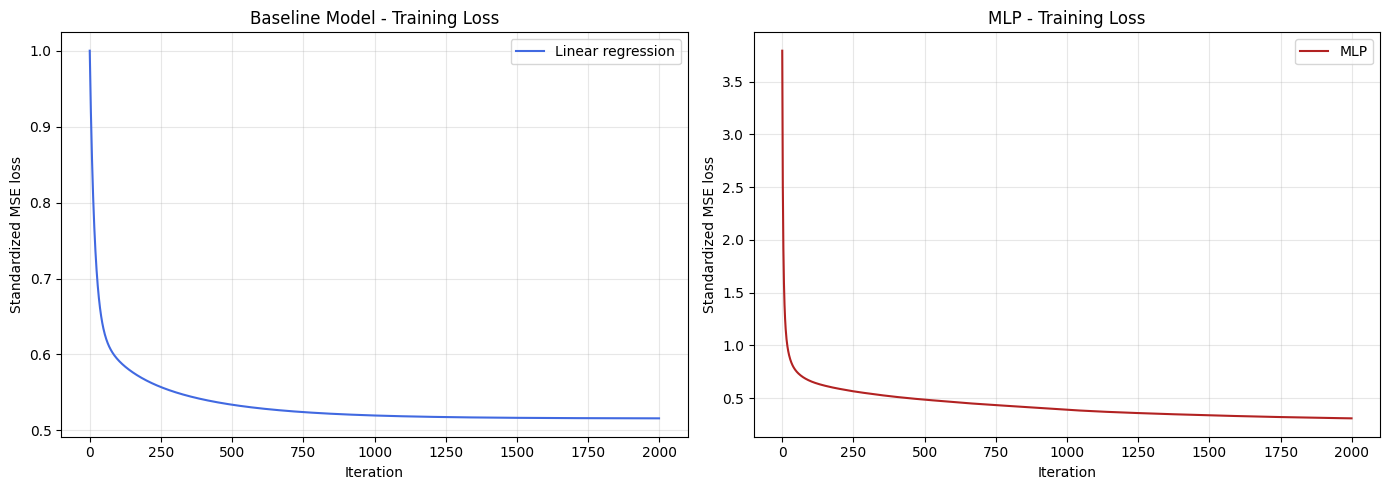

In [9]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label='Linear regression', color='royalblue')
plt.xlabel('Iteration')
plt.ylabel('Standardized MSE loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label='MLP', color='firebrick')
plt.xlabel('Iteration')
plt.ylabel('Standardized MSE loss')
plt.title('MLP - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

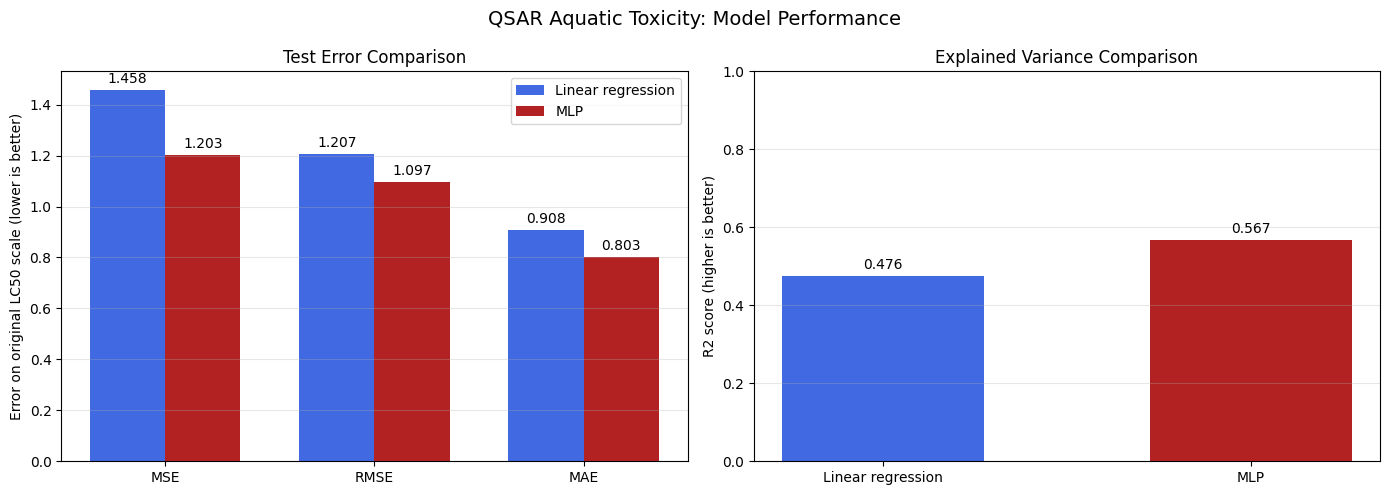

In [10]:
# 2. Performance comparison bar chart
error_names = ['MSE', 'RMSE', 'MAE']
baseline_errors = [baseline_metrics[name] for name in error_names]
mlp_errors = [mlp_metrics[name] for name in error_names]
x_positions = np.arange(len(error_names))
bar_width = 0.36

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
baseline_bars = axes[0].bar(
    x_positions - bar_width / 2,
    baseline_errors,
    bar_width,
    label='Linear regression',
    color='royalblue'
)
mlp_bars = axes[0].bar(
    x_positions + bar_width / 2,
    mlp_errors,
    bar_width,
    label='MLP',
    color='firebrick'
)
axes[0].bar_label(baseline_bars, fmt='%.3f', padding=3)
axes[0].bar_label(mlp_bars, fmt='%.3f', padding=3)
axes[0].set_xticks(x_positions, error_names)
axes[0].set_ylabel('Error on original LC50 scale (lower is better)')
axes[0].set_title('Test Error Comparison')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

r2_bars = axes[1].bar(
    ['Linear regression', 'MLP'],
    [baseline_r2, mlp_r2],
    color=['royalblue', 'firebrick'],
    width=0.55
)
axes[1].bar_label(r2_bars, fmt='%.3f', padding=3)
axes[1].set_ylabel('R2 score (higher is better)')
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title('Explained Variance Comparison')
axes[1].grid(True, axis='y', alpha=0.3)

figure.suptitle('QSAR Aquatic Toxicity: Model Performance', fontsize=14)
plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [11]:
analysis_text = f"""
The MLP achieved an R2 score of {mlp_r2:.3f}, compared with {baseline_r2:.3f} for
linear regression, an absolute improvement of {mlp_r2 - baseline_r2:.3f}. RMSE
decreased from {baseline_rmse:.3f} to {mlp_rmse:.3f} LC50 units, while MAE fell from
{baseline_mae:.3f} to {mlp_mae:.3f}. The MLP therefore performed better on every test
metric. This improvement is plausible because toxicity depends on nonlinear
interactions among molecular size, polarity, lipophilicity, connectivity, and
atom-centred fragments; a single linear equation cannot represent those relationships
flexibly. The trade-off was computation: linear regression trained in
{baseline_training_time:.4f} seconds, whereas the two-hidden-layer MLP required
{mlp_training_time:.4f} seconds and contained many more parameters. Both training
losses decreased consistently, supporting the correctness of the gradient calculations
and update rules. The most challenging step was scaling descriptors with very
different numerical ranges and scaling the target for stable neural-network
optimization. Predictions were converted back to the original LC50 scale before
evaluation, so the reported errors remain interpretable. The dataset is relatively
small, with 546 chemicals and 110 test examples, so individual observations can
noticeably affect the results. Overall, the experiment shows that a neural network
captures useful nonlinear structure and reduces prediction error, but its additional
complexity and training cost should be justified through clear and reliable
performance gains on unseen compounds.
""".strip()

print(analysis_text)
print(f"\nAnalysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

The MLP achieved an R2 score of 0.567, compared with 0.476 for
linear regression, an absolute improvement of 0.092. RMSE
decreased from 1.207 to 1.097 LC50 units, while MAE fell from
0.908 to 0.803. The MLP therefore performed better on every test
metric. This improvement is plausible because toxicity depends on nonlinear
interactions among molecular size, polarity, lipophilicity, connectivity, and
atom-centred fragments; a single linear equation cannot represent those relationships
flexibly. The trade-off was computation: linear regression trained in
0.0207 seconds, whereas the two-hidden-layer MLP required
0.1871 seconds and contained many more parameters. Both training
losses decreased consistently, supporting the correctness of the gradient calculations
and update rules. The most challenging step was scaling descriptors with very
different numerical ranges and scaling the target for stable neural-network
optimization. Predictions were converted back to the original LC50 scale befor

---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.


⭐⭐⭐ REQUIRED: Structured Output Function ⭐⭐⭐

### 🚨 CRITICAL - READ CAREFULLY 🚨

1. **Fill in ALL fields** - Missing fields = 0 marks
2. **Use your actual values** - Not 0 or empty strings
3. **This cell MUST be executed** - We need the output!
4. **Print the results** - Auto-grader needs to see output!


**DO NOT:**
- Leave any field as 0, 0.0,
- Clear outputs before submission
- Modify the structure


"**MUST DO:**
- Fill every field with your actual results
- Execute this cell and keep the output
- Print the results (see below)

In [12]:
def get_assignment_results():
    '''
    CRITICAL: Fill ALL fields with your actual results!
    Missing fields will result in 0 marks for that section.
    '''

    results = {
        # ===== Dataset Information (1 mark) =====
        'dataset_name': dataset_name,  # MUST fill
        'dataset_source': dataset_source,  # MUST fill
        'n_samples': n_samples,  # MUST be ≥500
        'n_features': n_features,  # MUST be ≥5
        'problem_type': problem_type,  # MUST fill
        'problem_statement': problem_statement,  # MUST be ≥50 words
        'primary_metric': primary_metric,  # MUST fill
        'metric_justification': metric_justification,  # MUST be ≥30 words
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # ===== Baseline Model (3 marks) =====
        'baseline_model': {
            'model_type': 'linear_regression',  # 'linear_regression', 'logistic_regression', 'softmax_regression'
            'learning_rate': 0.01,  # Your learning rate
            'n_iterations': 2000,  # Your iterations

            # CRITICAL: These MUST be filled!
            'initial_loss': baseline_initial_loss,  # MUST NOT be 0
            'final_loss': baseline_final_loss,  # MUST NOT be 0
            'training_time_seconds': baseline_training_time,  # MUST NOT be 0
            'loss_decreased': baseline_final_loss < baseline_initial_loss,  # Auto-calculated

            # Metrics - Fill based on your problem type
            'test_accuracy': 0.0 if problem_type == 'regression' else baseline_acc,
            'test_precision': 0.0 if problem_type == 'regression' else baseline_prec,
            'test_recall': 0.0 if problem_type == 'regression' else baseline_rec,
            'test_f1': 0.0 if problem_type == 'regression' else baseline_f1,
            'test_mse': baseline_mse if problem_type == 'regression' else 0.0,
            'test_rmse': baseline_rmse if problem_type == 'regression' else 0.0,
            'test_mae': baseline_mae if problem_type == 'regression' else 0.0,
            'test_r2': baseline_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== MLP Model (4 marks) =====
        'mlp_model': {
            'architecture': mlp_architecture,  # MUST have ≥3 elements
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'learning_rate': 0.005,
            'n_iterations': 2000,

            # CRITICAL: These MUST be filled!
            'initial_loss': mlp_initial_loss,  # MUST NOT be 0
            'final_loss': mlp_final_loss,  # MUST NOT be 0
            'training_time_seconds': mlp_training_time,  # MUST NOT be 0
            'loss_decreased': mlp_final_loss < mlp_initial_loss,  # Auto-calculated

            # Metrics
            'test_accuracy': 0.0 if problem_type == 'regression' else mlp_acc,
            'test_precision': 0.0 if problem_type == 'regression' else mlp_prec,
            'test_recall': 0.0 if problem_type == 'regression' else mlp_rec,
            'test_f1': 0.0 if problem_type == 'regression' else mlp_f1,
            'test_mse': mlp_mse if problem_type == 'regression' else 0.0,
            'test_rmse': mlp_rmse if problem_type == 'regression' else 0.0,
            'test_mae': mlp_mae if problem_type == 'regression' else 0.0,
            'test_r2': mlp_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== Analysis (2 marks) =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
    }

    return results

# ===== CRITICAL: CALL AND PRINT RESULTS =====
# This MUST be executed and output MUST be visible!
import json
results = get_assignment_results()
print(json.dumps(results, indent=2))

# ===== Validation =====
print("\n" + "="*60)
print("VALIDATION CHECK")
print("="*60)


errors = []

if results['n_samples'] < 500:
    errors.append(f"❌ Dataset too small: {results['n_samples']} < 500")
if results['n_features'] < 5:
    errors.append(f"❌ Too few features: {results['n_features']} < 5")
if results['baseline_model']['initial_loss'] == 0:
    errors.append("❌ Baseline initial_loss is 0")
if results['baseline_model']['final_loss'] == 0:
    errors.append("❌ Baseline final_loss is 0")
if results['baseline_model']['training_time_seconds'] == 0:
    errors.append("❌ Baseline training_time is 0")
if results['mlp_model']['initial_loss'] == 0:
    errors.append("❌ MLP initial_loss is 0")
if results['mlp_model']['final_loss'] == 0:
    errors.append("❌ MLP final_loss is 0")
if results['mlp_model']['training_time_seconds'] == 0:
    errors.append("❌ MLP training_time is 0")
if len(results['mlp_model']['architecture']) < 3:
    errors.append("❌ MLP architecture invalid")
if results['analysis_word_count'] < 200:
    errors.append(f"❌ Analysis too short: {results['analysis_word_count']} < 200 words")

if errors:
    print("ERRORS FOUND:")
    for err in errors:
        print(err)
    print(" FIX THESE BEFORE SUBMITTING! ")
else:
    print("✅ All validation checks passed!")
    print("✅ Ready to submit!")
    print("Next steps:")
    print("1. Kernel → Restart & Clear Output")
    print("2. Kernel → Restart & Run All")
    print("3. Verify this output is visible")
    print("4. Save notebook")
    print("5. Rename as: YourStudentID_assignment.ipynb")
    print("6. Submit to LMS")

{
  "dataset_name": "QSAR Aquatic Toxicity",
  "dataset_source": "UCI Machine Learning Repository, DOI: 10.24432/C5SG7H",
  "n_samples": 546,
  "n_features": 8,
  "problem_type": "regression",
  "problem_statement": "This regression task estimates the acute aquatic toxicity of a chemical toward\nDaphnia magna from eight molecular descriptors. The continuous target is LC50\nexpressed as negative log molar concentration; higher values indicate greater\ntoxicity at lower concentrations. Accurate screening can help prioritize compounds\nfor laboratory testing and environmental risk assessment while reducing time, cost,\nand animal testing requirements.",
  "primary_metric": "rmse",
  "metric_justification": "RMSE is primary because it measures prediction error in target units and penalizes\nlarge mistakes more strongly than MAE. Large toxicity errors could mis-rank hazardous\nchemicals, so emphasizing them is appropriate, while R2 provides complementary\nexplanatory context.",
  "train_sam

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [13]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2))
    print("\n" + "="*70)


    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "QSAR Aquatic Toxicity",
  "dataset_source": "UCI Machine Learning Repository, DOI: 10.24432/C5SG7H",
  "n_samples": 546,
  "n_features": 8,
  "problem_type": "regression",
  "problem_statement": "This regression task estimates the acute aquatic toxicity of a chemical toward\nDaphnia magna from eight molecular descriptors. The continuous target is LC50\nexpressed as negative log molar concentration; higher values indicate greater\ntoxicity at lower concentrations. Accurate screening can help prioritize compounds\nfor laboratory testing and environmental risk assessment while reducing time, cost,\nand animal testing requirements.",
  "primary_metric": "rmse",
  "metric_justification": "RMSE is primary because it measures prediction error in target units and penalizes\nlarge mistakes more strongly than MAE. Large toxicity errors could mis-rank hazardous\nchemicals, so emphasizing them is appropriate, while R2 provides complementary\nexplanat

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

**Good luck! **